In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All imports done!")

All imports done!


In [6]:
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

print("TRAIN DATASET:")
print(f"  Rows: {len(train_df):,}")
print(f"  Columns: {train_df.shape[1]}")

print("\nTEST DATASET:")
print(f"  Rows: {len(test_df):,}")
print(f"  Columns: {test_df.shape[1]}")

print("\nCOLUMN NAMES:")
print(train_df.columns.tolist())

print("\nFIRST 3 ROWS:")
train_df.head(3)

TRAIN DATASET:
  Rows: 1,296,675
  Columns: 23

TEST DATASET:
  Rows: 555,719
  Columns: 23

COLUMN NAMES:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

FIRST 3 ROWS:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


In [7]:
# Check fraud vs legit distribution
print("FRAUD DISTRIBUTION:")
print(train_df['is_fraud'].value_counts())
print(f"\nFraud %: {train_df['is_fraud'].mean() * 100:.2f}%")
print(f"Legit %: {(1 - train_df['is_fraud'].mean()) * 100:.2f}%")

# Check for missing values
print("\nMISSING VALUES:")
print(train_df.isnull().sum().sum(), "total missing values")

# Check column data types
print("\nDATA TYPES:")
print(train_df.dtypes)

FRAUD DISTRIBUTION:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud %: 0.58%
Legit %: 99.42%

MISSING VALUES:
0 total missing values

DATA TYPES:
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


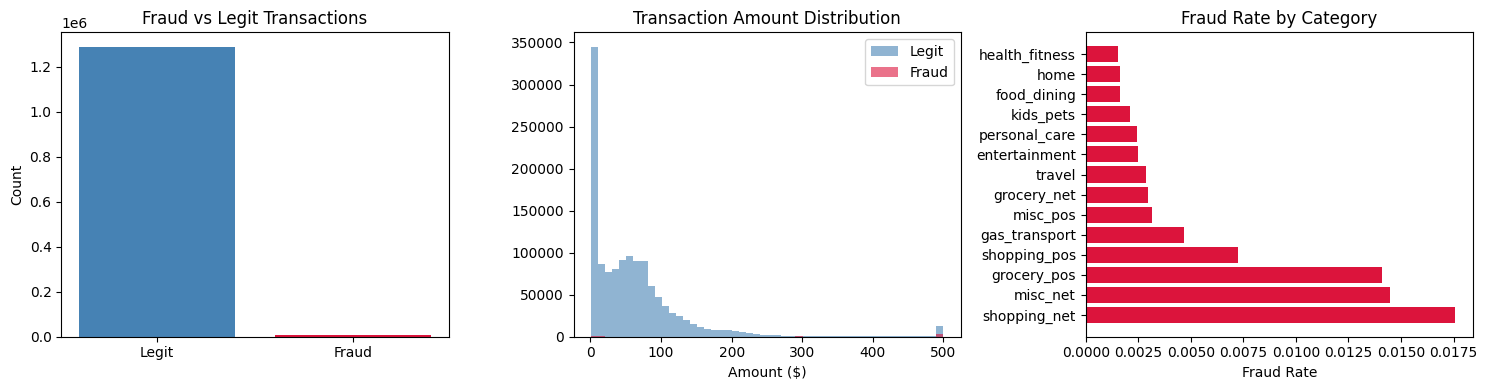

Top fraud categories:
category
shopping_net     0.017561
misc_net         0.014458
grocery_pos      0.014098
shopping_pos     0.007225
gas_transport    0.004694
Name: is_fraud, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Fraud vs Legit count
axes[0].bar(['Legit', 'Fraud'], 
            [train_df['is_fraud'].value_counts()[0], train_df['is_fraud'].value_counts()[1]],
            color=['steelblue', 'crimson'])
axes[0].set_title('Fraud vs Legit Transactions')
axes[0].set_ylabel('Count')

# Chart 2: Transaction amount distribution
axes[1].hist(train_df[train_df['is_fraud']==0]['amt'].clip(0, 500), 
             bins=50, alpha=0.6, label='Legit', color='steelblue')
axes[1].hist(train_df[train_df['is_fraud']==1]['amt'].clip(0, 500), 
             bins=50, alpha=0.6, label='Fraud', color='crimson')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount ($)')
axes[1].legend()

# Chart 3: Fraud by category
fraud_by_cat = train_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
axes[2].barh(fraud_by_cat.index, fraud_by_cat.values, color='crimson')
axes[2].set_title('Fraud Rate by Category')
axes[2].set_xlabel('Fraud Rate')

plt.tight_layout()
plt.show()

print("Top fraud categories:")
print(fraud_by_cat.head(5))

In [9]:
# Parse the datetime column (it's currently a string, we need it as actual datetime)
train_df['trans_dt'] = pd.to_datetime(train_df['trans_date_trans_time'])
test_df['trans_dt']  = pd.to_datetime(test_df['trans_date_trans_time'])

# Extract time-based features
for df in [train_df, test_df]:
    df['hour']       = df['trans_dt'].dt.hour
    df['day_of_week']= df['trans_dt'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['month']      = df['trans_dt'].dt.month
    df['is_night']   = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Customer age from date of birth
for df in [train_df, test_df]:
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = (df['trans_dt'] - df['dob']).dt.days // 365

print("Sample of new features:")
train_df[['trans_date_trans_time', 'hour', 'day_of_week', 'is_night', 'is_weekend', 'age']].head(5)

Sample of new features:


,trans_date_trans_time,hour,day_of_week,is_night,is_weekend,age
0,2019-01-01 00:00:18,0,1,1,0,30
1,2019-01-01 00:00:44,0,1,1,0,40
2,2019-01-01 00:00:51,0,1,1,0,56
3,2019-01-01 00:01:16,0,1,1,0,52
4,2019-01-01 00:03:06,0,1,1,0,32


In [10]:
# Haversine formula — calculates real-world distance between 2 GPS coordinates
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Distance from cardholder's HOME address to the merchant
for df in [train_df, test_df]:
    df['dist_home_to_merchant'] = haversine(
        df['lat'].values,       # cardholder home lat
        df['long'].values,      # cardholder home long
        df['merch_lat'].values, # merchant lat
        df['merch_long'].values # merchant long
    )

print("Distance stats (km):")
print(train_df['dist_home_to_merchant'].describe().round(2))

print("\nFraud vs Legit — avg distance from home:")
print(train_df.groupby('is_fraud')['dist_home_to_merchant'].mean().round(2))

Distance stats (km):
count    1296675.00
mean          76.11
std           29.12
min            0.02
25%           55.33
50%           78.23
75%           98.50
max          152.12
Name: dist_home_to_merchant, dtype: float64

Fraud vs Legit — avg distance from home:
is_fraud
0    76.11
1    76.27
Name: dist_home_to_merchant, dtype: float64


In [11]:
# Sort by card number + time so consecutive rows = consecutive transactions
train_df = train_df.sort_values(['cc_num', 'unix_time']).reset_index(drop=True)
test_df  = test_df.sort_values(['cc_num', 'unix_time']).reset_index(drop=True)

for df in [train_df, test_df]:
    # Previous transaction's merchant location (per card)
    df['prev_merch_lat']  = df.groupby('cc_num')['merch_lat'].shift(1)
    df['prev_merch_long'] = df.groupby('cc_num')['merch_long'].shift(1)
    df['prev_unix_time']  = df.groupby('cc_num')['unix_time'].shift(1)

    # Distance between consecutive merchant locations (km)
    df['consec_dist_km'] = haversine(
        df['prev_merch_lat'].fillna(df['merch_lat']).values,
        df['prev_merch_long'].fillna(df['merch_long']).values,
        df['merch_lat'].values,
        df['merch_long'].values
    )

    # Time gap between consecutive transactions (hours)
    df['time_gap_hours'] = (
        df['unix_time'] - df['prev_unix_time'].fillna(df['unix_time'])
    ) / 3600

    # Speed in km/h — THE impossible traveler signal
    df['travel_speed_kmh'] = np.where(
        df['time_gap_hours'] > 0,
        df['consec_dist_km'] / df['time_gap_hours'],
        0
    )

    # Flag suspicious speeds
    df['is_impossible_traveler'] = (df['travel_speed_kmh'] > 500).astype(int)
    df['is_fast_traveler']       = (df['travel_speed_kmh'] > 200).astype(int)

print("Impossible Traveler stats:")
print(train_df.groupby('is_fraud')[['travel_speed_kmh', 'is_impossible_traveler']].mean().round(4))

print(f"\nImpossible traveler cases: {train_df['is_impossible_traveler'].sum():,}")
print(f"Of those, % that are fraud: {train_df[train_df['is_impossible_traveler']==1]['is_fraud'].mean()*100:.2f}%")


Impossible Traveler stats:
          travel_speed_kmh  is_impossible_traveler
is_fraud                                          
0                 185.6672                  0.0373
1                 741.6401                  0.1411

Impossible traveler cases: 49,151
Of those, % that are fraud: 2.15%


In [12]:
for df in [train_df, test_df]:
    # How many transactions on this card in the last hour / day
    df['trans_dt_hour'] = df['trans_dt'].dt.floor('h')
    df['trans_dt_day']  = df['trans_dt'].dt.floor('D')
    
    df['tx_count_1h']  = df.groupby(['cc_num', 'trans_dt_hour'])['amt'].transform('count')
    df['tx_count_1d']  = df.groupby(['cc_num', 'trans_dt_day'])['amt'].transform('count')

    # Amount change from previous transaction
    df['prev_amt'] = df.groupby('cc_num')['amt'].shift(1)
    df['amt_change_ratio'] = np.where(
        df['prev_amt'] > 0,
        df['amt'] / df['prev_amt'].fillna(df['amt']),
        1
    )

    # Per-card spending baseline (how normal is THIS transaction for THIS card?)
    card_stats = df.groupby('cc_num')['amt'].agg(['mean', 'std']).reset_index()
    card_stats.columns = ['cc_num', 'card_avg_amt', 'card_std_amt']
    df.drop(columns=[c for c in ['card_avg_amt','card_std_amt'] if c in df.columns], inplace=True)
    df.merge(card_stats, on='cc_num', how='left').pipe(lambda x: df.update(x) or df)

    # How many std deviations away from this card's normal spend?
    df['card_avg_amt'] = df.groupby('cc_num')['amt'].transform('mean')
    df['card_std_amt'] = df.groupby('cc_num')['amt'].transform('std').fillna(1)
    df['amt_zscore']   = (df['amt'] - df['card_avg_amt']) / df['card_std_amt']
    df['is_amt_anomaly'] = (df['amt_zscore'] > 3).astype(int)

print("Velocity features — fraud vs legit:")
print(train_df.groupby('is_fraud')[['tx_count_1h', 'tx_count_1d', 'amt_zscore']].mean().round(3))

print("\nAmount anomaly fraud rate:")
print(f"Normal transactions fraud rate:  {train_df[train_df['is_amt_anomaly']==0]['is_fraud'].mean()*100:.2f}%")
print(f"Anomaly transactions fraud rate: {train_df[train_df['is_amt_anomaly']==1]['is_fraud'].mean()*100:.2f}%")

Velocity features — fraud vs legit:
          tx_count_1h  tx_count_1d  amt_zscore
is_fraud                                      
0               1.188        4.992      -0.019
1               1.828        6.032       3.204

Amount anomaly fraud rate:
Normal transactions fraud rate:  0.34%
Anomaly transactions fraud rate: 16.97%


In [ ]:
# Label encode categorical columns (model needs numbers not text)
le_gender   = LabelEncoder()
le_state    = LabelEncoder()
le_category = LabelEncoder()

for df in [train_df, test_df]:
    df['gender_enc']   = le_gender.fit_transform(df['gender'].astype(str))
    df['state_enc']    = le_state.fit_transform(df['state'].astype(str))
    df['category_enc'] = le_category.fit_transform(df['category'].astype(str))

# Category fraud rate — how risky is this spending category historically?
cat_fraud_rate = train_df.groupby('category')['is_fraud'].mean().to_dict()
train_df['category_fraud_rate'] = train_df['category'].map(cat_fraud_rate)
test_df['category_fraud_rate']  = test_df['category'].map(cat_fraud_rate).fillna(0.005)

# Final list of features we'll feed into the model
FEATURES = [
    # Transaction basics
    'amt', 'hour', 'day_of_week', 'month', 'is_night', 'is_weekend',
    # Demographics  
    'age', 'gender_enc', 'city_pop',
    # Geography
    'dist_home_to_merchant',
    #  Impossible Traveler
    'consec_dist_km', 'time_gap_hours', 'travel_speed_kmh',
    'is_impossible_traveler', 'is_fast_traveler',
    # Velocity
    'tx_count_1h', 'tx_count_1d', 'amt_change_ratio',
    # Behavioral Profile
    'amt_zscore', 'card_avg_amt', 'card_std_amt',
    'is_amt_anomaly', 'category_fraud_rate',
    # Encoding
    'state_enc', 'category_enc',
]

TARGET = 'is_fraud'

print(f"Total features: {len(FEATURES)}")
print("\nFeature list:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2}. {f}")

Total features: 25

Feature list:
   1. amt
   2. hour
   3. day_of_week
   4. month
   5. is_night
   6. is_weekend
   7. age
   8. gender_enc
   9. city_pop
  10. dist_home_to_merchant
  11. consec_dist_km
  12. time_gap_hours
  13. travel_speed_kmh
  14. is_impossible_traveler
  15. is_fast_traveler
  16. tx_count_1h
  17. tx_count_1d
  18. amt_change_ratio
  19. amt_zscore
  20. card_avg_amt
  21. card_std_amt
  22. is_amt_anomaly
  23. category_fraud_rate
  24. state_enc
  25. category_enc


In [14]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nFraud in train: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test:  {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

# Calculate class weight to handle imbalance
# This tells the model "hey fraud is rare, weight it more heavily"
fraud_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass weight ratio: {fraud_weight:.1f}x")
print("(model will penalize missing fraud this many times more than missing legit)")

X_train shape: (1296675, 25)
X_test shape:  (555719, 25)

Fraud in train: 7,506 (0.58%)
Fraud in test:  2,145 (0.39%)

Class weight ratio: 171.8x
(model will penalize missing fraud this many times more than missing legit)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# We'll use GradientBoostingClassifier — same family as XGBoost
model = GradientBoostingClassifier(
    n_estimators=200,      # 200 trees
    max_depth=5,           # how deep each tree goes
    learning_rate=0.1,     # how fast it learns
    subsample=0.8,         # use 80% of data per tree (prevents overfitting)
    random_state=42,
    verbose=1              # prints progress so you know it's working
)

print("Training started... this will take a few minutes ")
model.fit(X_train, y_train)
print("\nTraining complete!")

Training started... this will take a few minutes ⏳
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.0320           0.0423           24.50m
         2           0.0284           0.0035           24.07m
         3           0.0270           0.0021           23.67m
         4           0.0251          -0.0006           23.41m
         5           0.0310           0.0019           23.21m
         6           0.0301           0.0019           23.03m
         7           0.0226          -0.0265           22.88m
         8           0.0287           0.0284           22.74m
         9           0.0274           0.0002           22.61m
        10           0.2132          -0.1387           22.49m
        20           0.1627           0.0421           21.24m
        30           0.1754           0.1216           20.09m
        40           0.1366          -0.1014           18.87m
        50           0.1502           0.0141           17.68m
        60        

In [16]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, f1_score, precision_recall_curve,
                             average_precision_score)

# Get predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]  # fraud probability 0-1
y_pred       = model.predict(X_test)               # hard prediction 0 or 1

# Core metrics
auc  = roc_auc_score(y_test, y_pred_proba)
ap   = average_precision_score(y_test, y_pred_proba)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print(f"AUC-ROC Score    : {auc:.4f}  (1.0 = perfect, 0.5 = random)")
print(f"Avg Precision    : {ap:.4f}")
print(f"F1 Score         : {f1:.4f}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives  (legit caught correctly) : {cm[0,0]:,}")
print(f"  False Positives (legit flagged as fraud) : {cm[0,1]:,}")
print(f"  False Negatives (fraud missed!)          : {cm[1,0]:,}")
print(f"  True Positives  (fraud caught!)          : {cm[1,1]:,}")

print(f"\nOf {y_test.sum():,} real fraud cases:")
print(f"  Caught : {cm[1,1]:,} ({cm[1,1]/y_test.sum()*100:.1f}%)")
print(f"  Missed : {cm[1,0]:,} ({cm[1,0]/y_test.sum()*100:.1f}%)")

print(f"\n{classification_report(y_test, y_pred, target_names=['Legit','Fraud'])}")

AUC-ROC Score    : 0.9849  (1.0 = perfect, 0.5 = random)
Avg Precision    : 0.7402
F1 Score         : 0.8085

Confusion Matrix:
  True Negatives  (legit caught correctly) : 553,168
  False Positives (legit flagged as fraud) : 406
  False Negatives (fraud missed!)          : 414
  True Positives  (fraud caught!)          : 1,731

Of 2,145 real fraud cases:
  Caught : 1,731 (80.7%)
  Missed : 414 (19.3%)

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    553574
       Fraud       0.81      0.81      0.81      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.90      0.90    555719
weighted avg       1.00      1.00      1.00    555719



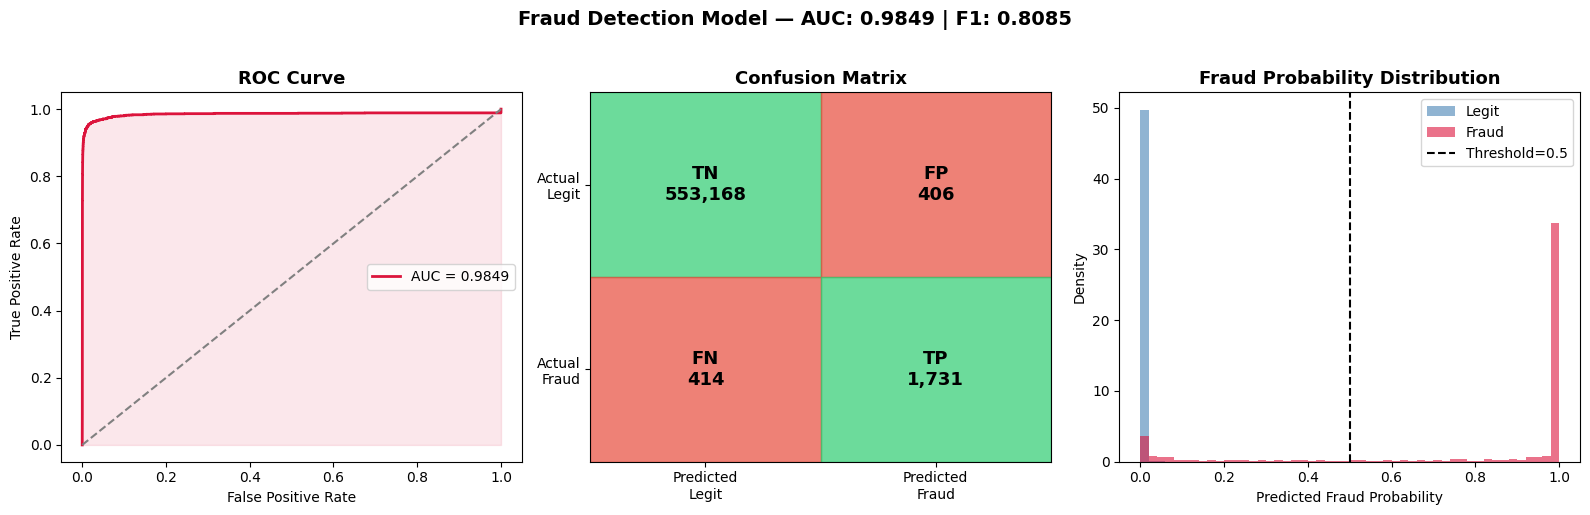

In [17]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1], '--', color='gray')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='crimson')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Chart 2: Confusion Matrix
cm_labels = [['TN\n553,168', 'FP\n406'], ['FN\n414', 'TP\n1,731']]
colors = [['#2ecc71', '#e74c3c'], ['#e74c3c', '#2ecc71']]
for i in range(2):
    for j in range(2):
        axes[1].add_patch(plt.Rectangle((j, 1-i), 1, 1, 
                          color=colors[i][j], alpha=0.7))
        axes[1].text(j+0.5, 1.5-i, cm_labels[i][j], 
                    ha='center', va='center', fontsize=13, fontweight='bold')
axes[1].set_xlim(0,2); axes[1].set_ylim(0,2)
axes[1].set_xticks([0.5,1.5]); axes[1].set_yticks([0.5,1.5])
axes[1].set_xticklabels(['Predicted\nLegit','Predicted\nFraud'])
axes[1].set_yticklabels(['Actual\nFraud','Actual\nLegit'])
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Chart 3: Fraud probability score distribution
axes[2].hist(y_pred_proba[y_test==0], bins=50, alpha=0.6, 
             color='steelblue', label='Legit', density=True)
axes[2].hist(y_pred_proba[y_test==1], bins=50, alpha=0.6, 
             color='crimson', label='Fraud', density=True)
axes[2].axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[2].set_title('Fraud Probability Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Predicted Fraud Probability')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle(f'Fraud Detection Model — AUC: {auc:.4f} | F1: {f1:.4f}', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import pickle
import json

# Save the trained model
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save metadata (features, thresholds, fraud rates)
meta = {
    'features': FEATURES,
    'threshold': 0.5,
    'auc_roc': float(auc),
    'f1_score': float(f1),
    'category_fraud_rate': cat_fraud_rate,
}
with open('model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(" Model saved → fraud_model.pkl")
print(" Metadata saved → model_meta.json")
print("\nThese 2 files are everything we need for the website!")

✅ Model saved → fraud_model.pkl
✅ Metadata saved → model_meta.json

These 2 files are everything we need for the website!
